In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers


2026-02-01 09:18:43.638251: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-01 09:18:46.049857: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-01 09:18:52.318145: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
def generate_sine_wave(samples=10000):
    x = np.linspace(0, 100, samples)
    return np.sin(x)

series = generate_sine_wave()


In [3]:
np.random.seed(42)

series_with_anomalies = series.copy()
anomaly_indices = np.random.choice(len(series), size=50, replace=False)

series_with_anomalies[anomaly_indices] += np.random.uniform(3, 5, size=50)


In [4]:
def create_sequences(data, window_size):
    sequences = []
    for i in range(len(data) - window_size):
        sequences.append(data[i:i + window_size])
    return np.array(sequences)

window_size = 50


In [5]:
train_sequences = create_sequences(series, window_size)
train_sequences = train_sequences[..., np.newaxis]


In [6]:
autoencoder = keras.Sequential([
    layers.Input(shape=(window_size, 1)),

    # Encoder
    layers.LSTM(64, return_sequences=True),
    layers.LSTM(32, return_sequences=False),

    # Bottleneck representation
    layers.RepeatVector(window_size),

    # Decoder
    layers.LSTM(32, return_sequences=True),
    layers.LSTM(64, return_sequences=True),

    layers.TimeDistributed(layers.Dense(1))
])


2026-02-01 09:20:48.768253: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [7]:
autoencoder.compile(
    optimizer="adam",
    loss="mse"
)


In [8]:
history = autoencoder.fit(
    train_sequences,
    train_sequences,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    shuffle=True
)


Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 27s 140ms/step - loss: 0.0537 - val_loss: 0.0195
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 19s 132ms/step - loss: 0.0147 - val_loss: 0.0114
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 21s 150ms/step - loss: 0.0064 - val_loss: 0.0019
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 144ms/step - loss: 0.0014 - val_loss: 6.8504e-04
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 141ms/step - loss: 4.6298e-04 - val_loss: 4.6845e-04
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 19s 134ms/step - loss: 3.0587e-04 - val_loss: 1.6146e-04
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 18s 126ms/step - loss: 4.4602e-04 - val_loss: 3.9624e-04
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 19s 137ms/step - loss: 1.2872e-04 - val_loss: 1.2359e-04
Epoch 9/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 19s 134ms/step - loss: 7.6536e-05 - val_loss: 6.4995e-05
Epoch 10/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 18s 131ms/step - loss: 1.3492e-04 - val_loss: 4.9766e-05


In [9]:
all_sequences = create_sequences(series_with_anomalies, window_size)
all_sequences = all_sequences[..., np.newaxis]


In [10]:
reconstructions = autoencoder.predict(all_sequences)


311/311 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step


In [11]:
reconstruction_error = np.mean(
    np.square(all_sequences - reconstructions),
    axis=(1, 2)
)


In [12]:
train_reconstructions = autoencoder.predict(train_sequences)

train_error = np.mean(
    np.square(train_sequences - train_reconstructions),
    axis=(1, 2)
)

threshold = np.percentile(train_error, 95)
print("Anomaly threshold:", threshold)


311/311 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step
Anomaly threshold: 0.00015017387634139507


In [13]:
anomalies = reconstruction_error > threshold


In [14]:
anomaly_points = np.where(anomalies)[0] + window_size


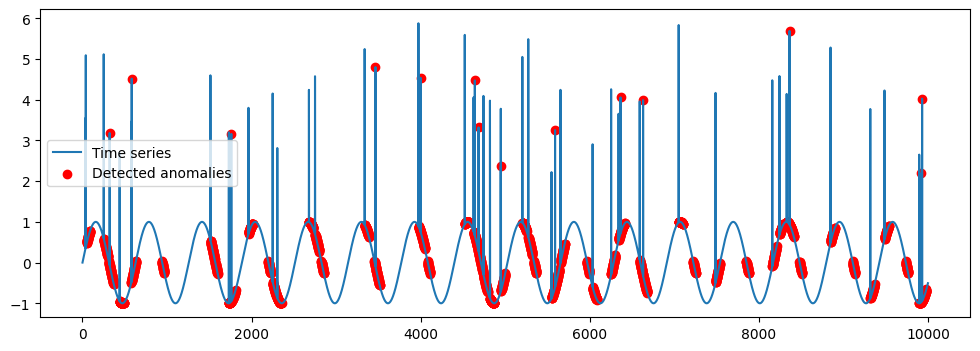

In [15]:
plt.figure(figsize=(12, 4))
plt.plot(series_with_anomalies, label="Time series")

plt.scatter(
    anomaly_points,
    series_with_anomalies[anomaly_points],
    color="red",
    label="Detected anomalies"
)

plt.legend()
plt.show()
